### Cell 1: Import libraries and set paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Directories ready")

Directories ready


### Cell 2: Load the CSV files

In [2]:
# Load events (large, may take a few seconds)
events = pd.read_csv(RAW_DIR / "events.csv")
category_tree = pd.read_csv(RAW_DIR / "category_tree.csv")
item_props1 = pd.read_csv(RAW_DIR / "item_properties_part1.csv")
item_props2 = pd.read_csv(RAW_DIR / "item_properties_part2.csv")

print(f"events shape: {events.shape}")
print(f"category_tree shape: {category_tree.shape}")
print(f"item_props1 shape: {item_props1.shape}")
print(f"item_props2 shape: {item_props2.shape}")

events shape: (2756101, 5)
category_tree shape: (1669, 2)
item_props1 shape: (10999999, 4)
item_props2 shape: (9275903, 4)


### Cell 3: Basic EDA events

In [3]:
events.head()
events.info()
events.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


### Cell 4: Event type distribution

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


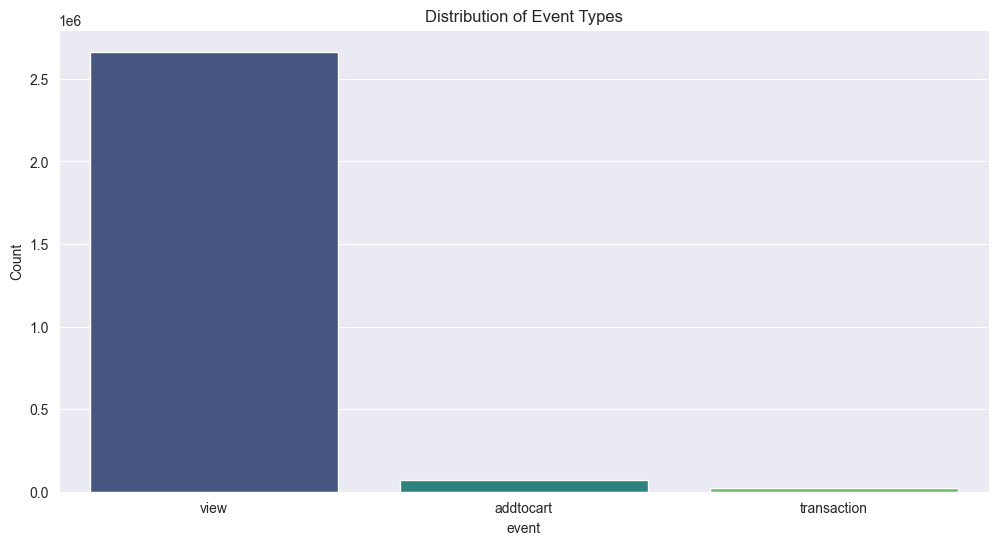

In [4]:
# Check event types
event_counts = events['event'].value_counts()
print(event_counts)

plt.figure()
sns.barplot(x=event_counts.index, y=event_counts.values, palette='viridis')
plt.title('Distribution of Event Types')
plt.ylabel('Count')
plt.show()

### Cell 5: Time range of events

In [5]:
# Convert timestamp to datetime
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')
print(f"Min timestamp: {events['timestamp'].min()}")
print(f"Max timestamp: {events['timestamp'].max()}")
print(f"Date range: {(events['timestamp'].max() - events['timestamp'].min()).days} days")

Min timestamp: 2015-05-03 03:00:04.384000
Max timestamp: 2015-09-18 02:59:47.788000
Date range: 137 days


### Cell 6: Unique visitors, items, transactions

In [6]:
print(f"Unique visitors: {events['visitorid'].nunique()}")
print(f"Unique items: {events['itemid'].nunique()}")
print(f"Unique transactions (non‑null transactionid): {events['transactionid'].nunique() - 1}")  # exclude NaN

Unique visitors: 1407580
Unique items: 235061
Unique transactions (non‑null transactionid): 17671


### Cell 7: Category tree exploration

In [7]:
category_tree.head()
category_tree.info()
print(f"Number of categories: {category_tree['categoryid'].nunique()}")
print(f"Root categories (parentid is NaN): {category_tree['parentid'].isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB
Number of categories: 1669
Root categories (parentid is NaN): 25


### Cell 8: Visualise depth of category tree

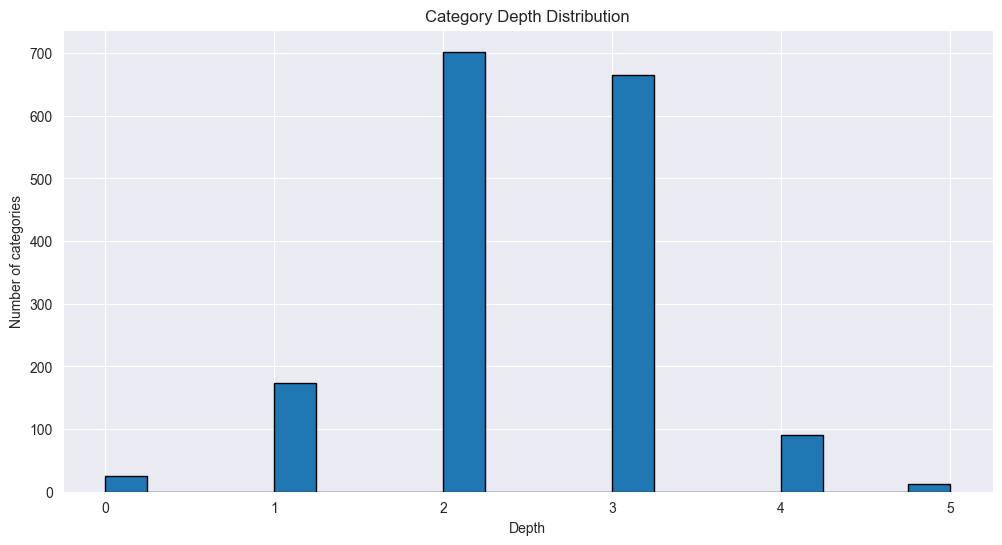

In [8]:
# Build parent mapping
parent_of = {}
for _, row in category_tree.iterrows():
    if pd.notna(row['parentid']):
        parent_of[int(row['categoryid'])] = int(row['parentid'])

def get_depth(cat_id, depth=0):
    if cat_id not in parent_of:
        return depth
    return get_depth(parent_of[cat_id], depth+1)

depths = [get_depth(cat) for cat in category_tree['categoryid'] if cat in parent_of or True]
plt.hist(depths, bins=20, edgecolor='black')
plt.title('Category Depth Distribution')
plt.xlabel('Depth')
plt.ylabel('Number of categories')
plt.show()

### Cell 9: Item properties: extract categoryid mapping

In [9]:
# Combine both parts
item_props = pd.concat([item_props1, item_props2], ignore_index=True)
print(f"Combined item_props shape: {item_props.shape}")

# Filter rows where property == "categoryid"
cat_rows = item_props[item_props['property'] == 'categoryid'].copy()
print(f"Rows with categoryid: {len(cat_rows)}")

# Keep only itemid and value (categoryid)
item_cat = cat_rows[['itemid', 'value']].drop_duplicates(subset=['itemid'])
item_cat.rename(columns={'value': 'categoryid'}, inplace=True)
print(f"Unique items with category mapping: {len(item_cat)}")
item_cat.head()

Combined item_props shape: (20275902, 4)
Rows with categoryid: 788214
Unique items with category mapping: 417053


,itemid,categoryid
0,460429,1338
140,281245,1277
151,35575,1059
189,8313,1147
197,55102,47


### Cell 10: Save item->category mapping

In [10]:
item_cat.to_csv(PROCESSED_DIR / "item_category_mapping.csv", index=False)
print("Saved to", PROCESSED_DIR / "item_category_mapping.csv")

Saved to ..\data\processed\item_category_mapping.csv


### Cell 11: Merge category names

In [11]:
# Convert categoryid to int (some values may be strings)
item_cat['categoryid'] = item_cat['categoryid'].astype(int)

# Now merge safely
item_cat_with_parent = item_cat.merge(category_tree, on='categoryid', how='left')
item_cat_with_parent.head()

,itemid,categoryid,parentid
0,460429,1338,1278.0
1,281245,1277,312.0
2,35575,1059,1696.0
3,8313,1147,1027.0
4,55102,47,381.0


### Cell 12: Create user sessions (time‑based)

In [12]:
# Sort and compute time differences per visitor
events_sorted = events.sort_values(['visitorid', 'timestamp']).copy()
events_sorted['time_diff_min'] = events_sorted.groupby('visitorid')['timestamp'].diff().dt.total_seconds() / 60.0

# New session if diff > 30 minutes or first event
events_sorted['session_id'] = (events_sorted['time_diff_min'] > 30).groupby(events_sorted['visitorid']).cumsum().fillna(0).astype(int)

print(f"Number of sessions: {events_sorted['session_id'].nunique()}")
events_sorted[['visitorid', 'timestamp', 'event', 'session_id', 'time_diff_min']].head(10)

Number of sessions: 462


,visitorid,timestamp,event,session_id,time_diff_min
1361687,0,2015-09-11 20:49:49.439,view,0,NaN
1367212,0,2015-09-11 20:52:39.591,view,0,2.835867
1367342,0,2015-09-11 20:55:17.175,view,0,2.626400
830385,1,2015-08-13 17:46:06.444,view,0,NaN
742616,2,2015-08-07 17:51:44.567,view,0,NaN
735273,2,2015-08-07 17:53:33.790,view,0,1.820383
737711,2,2015-08-07 17:56:52.664,view,0,3.314567
726292,2,2015-08-07 18:01:08.920,view,0,4.270933
737615,2,2015-08-07 18:08:25.669,view,0,7.279150
735202,2,2015-08-07 18:17:24.375,view,0,8.978433


### Cell 13: Aggregate session‑level features

In [13]:
# Pre‑map categoryid to each event row (vectorized)
events_sorted['categoryid'] = events_sorted['itemid'].map(
    item_cat.set_index('itemid')['categoryid']
)

# For rows where itemid has no category, fill with 0 or drop later
events_sorted['categoryid'] = events_sorted['categoryid'].fillna(0).astype(int)

# Now aggregate
session_features = events_sorted.groupby(['visitorid', 'session_id']).agg(
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max'),
    num_views=('event', lambda x: (x == 'view').sum()),
    num_addtocart=('event', lambda x: (x == 'addtocart').sum()),
    num_transactions=('event', lambda x: (x == 'transaction').sum()),
    unique_items=('itemid', 'nunique'),
    categories_viewed=('categoryid', 'nunique')   # much faster!
).reset_index()

# Add duration and purchase flag as before
session_features['duration_min'] = (session_features['end_time'] - session_features['start_time']).dt.total_seconds() / 60.0
session_features['purchased'] = (session_features['num_transactions'] > 0).astype(int)
session_features.head()

,visitorid,session_id,start_time,end_time,num_views,num_addtocart,num_transactions,unique_items,categories_viewed,duration_min,purchased
0,0,0,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,3,0,0,3,3,5.462267,0
1,1,0,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,1,0,0,1,1,0.000000,0
2,2,0,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,8,0,0,4,2,29.221300,0
3,3,0,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,1,0,0,1,1,0.000000,0
4,4,0,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,1,0,0,1,1,0.000000,0


### Cell 14: Save session features

In [14]:
session_features.to_parquet(PROCESSED_DIR / "user_sessions.parquet")
print("Saved sessions to", PROCESSED_DIR / "user_sessions.parquet")

Saved sessions to ..\data\processed\user_sessions.parquet


### Cell 15: Explore session features (EDA on sessions)

Session statistics:
Percentage of sessions with purchase: 0.81%


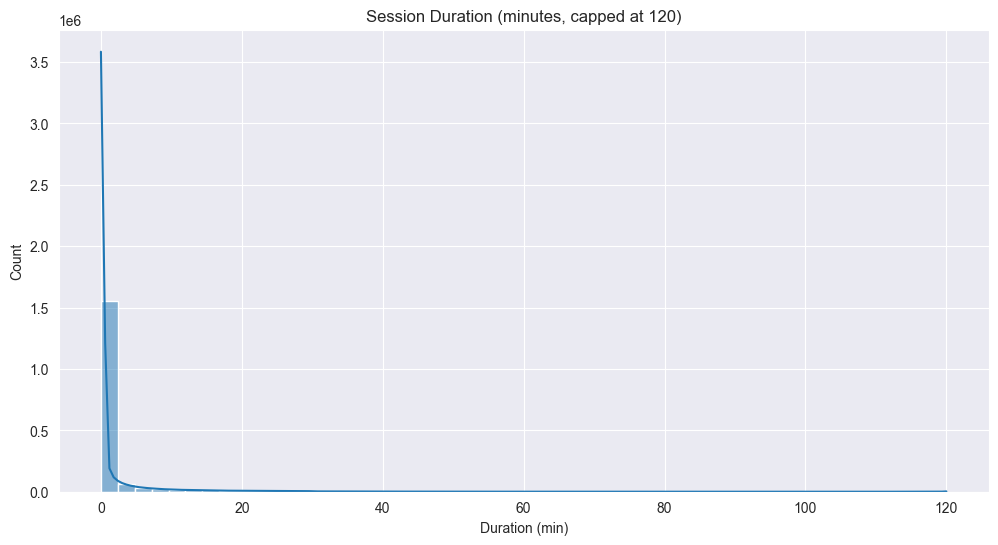

In [15]:
print("Session statistics:")
session_features.describe()

# Purchase rate
purchase_rate = session_features['purchased'].mean()
print(f"Percentage of sessions with purchase: {purchase_rate*100:.2f}%")

# Distribution of session duration
plt.figure()
sns.histplot(session_features['duration_min'].clip(upper=120), bins=50, kde=True)
plt.title('Session Duration (minutes, capped at 120)')
plt.xlabel('Duration (min)')
plt.show()

### Cell 16: Correlation heatmap

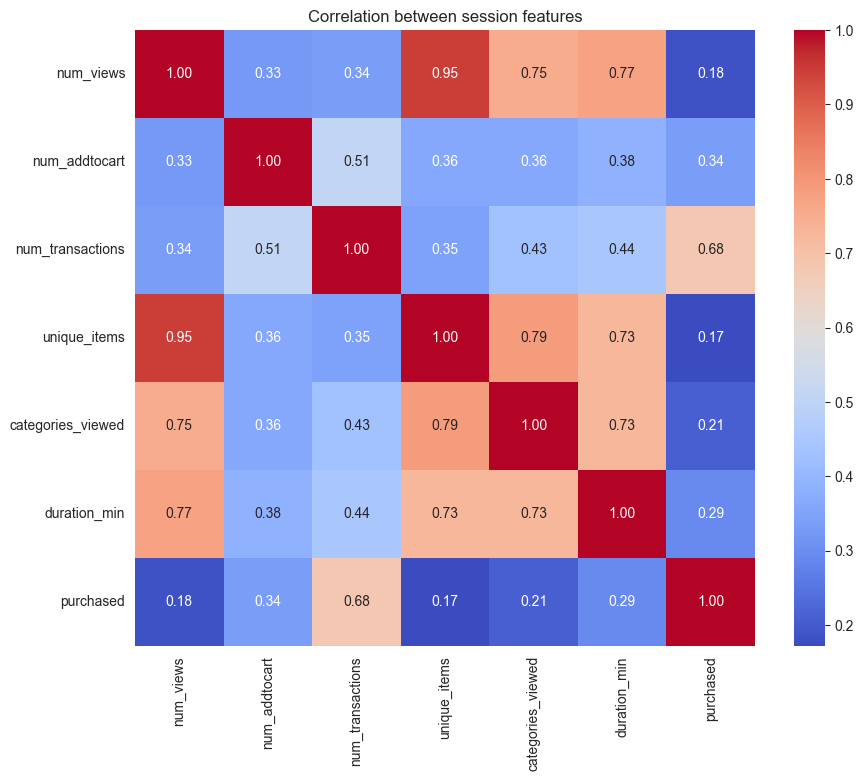

In [16]:
numeric_cols = ['num_views', 'num_addtocart', 'num_transactions', 'unique_items', 'categories_viewed', 'duration_min', 'purchased']
plt.figure(figsize=(10,8))
sns.heatmap(session_features[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between session features')
plt.show()

### Cell 17: Save events with session info for later use

In [17]:
# You may want to keep the events with session labels for detailed analysis
events_sorted.to_parquet(PROCESSED_DIR / "events_with_sessions.parquet")
print("Saved events with sessions to", PROCESSED_DIR / "events_with_sessions.parquet")

Saved events with sessions to ..\data\processed\events_with_sessions.parquet
